In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Download MNIST dataset automatically
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
    ])

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 60000
Testing samples: 10000


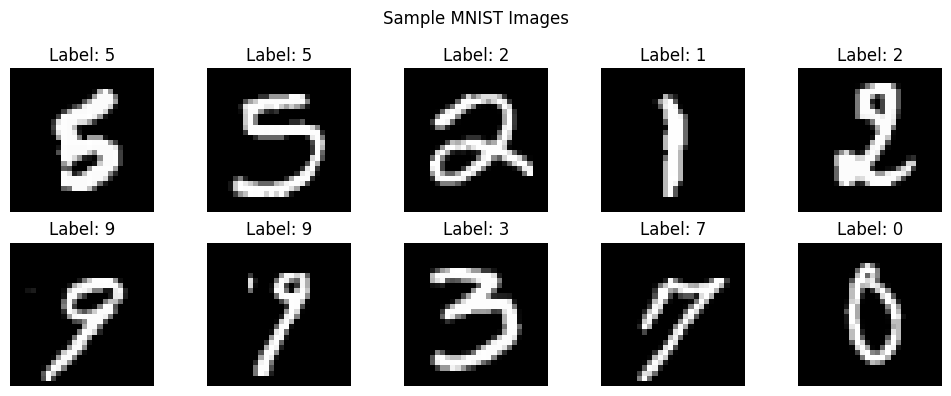

In [8]:
# See what the data looks like

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5,figsize=(10,4))
for i, ax in enumerate(axes.flat):
  ax.imshow(images[i].squeeze(), cmap="gray")
  ax.set_title(f"Label: {labels[i].item()}")
  ax.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [14]:
# Define the CNN

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_layers = nn.Sequential(
        # First convolution block
        nn.Conv2d(1, 32, kernel_size=3, padding=1), # 28x28 -> 28x28
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        # Second convolution block
        nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14 -> 14x14
        nn.ReLU(),
        nn.MaxPool2d(2,2),
    )

    self.fc_layers = nn.Sequential(
        nn.Flatten(),     # 64 * 7* & = 3136
        nn.Linear(3136, 128),
        nn.ReLU(),
        nn.Linear(128, 10)      # 10 output classes (digit 0-9)
    )

  def forward(self, x):
    x = self.conv_layers(x)
    x = self.fc_layers(x)
    return x

model = CNN()
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [17]:
# Train the CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train for # epochs
for epoch in range(3):
  model.train()
  running_loss =0

  for batch_idx, (images, labels) in enumerate(train_loader):
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if(batch_idx + 1) % 200 ==0:
      print(f"Epoch {epoch+1} | Batch {batch_idx+1} | Loss: {running_loss/200:.4f}")
      running_loss = 0

  print("\nTraining complete!")

Epoch 1 | Batch 200 | Loss: 0.0689
Epoch 1 | Batch 400 | Loss: 0.0751
Epoch 1 | Batch 600 | Loss: 0.0804
Epoch 1 | Batch 800 | Loss: 0.0765

Training complete!
Epoch 2 | Batch 200 | Loss: 0.0604
Epoch 2 | Batch 400 | Loss: 0.0658
Epoch 2 | Batch 600 | Loss: 0.0621
Epoch 2 | Batch 800 | Loss: 0.0642

Training complete!
Epoch 3 | Batch 200 | Loss: 0.0523
Epoch 3 | Batch 400 | Loss: 0.0593
Epoch 3 | Batch 600 | Loss: 0.0545
Epoch 3 | Batch 800 | Loss: 0.0701

Training complete!


In [18]:
# Evaluate Accuracy

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = correct / total * 100
print(f"CNN Test Accuracy: {accuracy:.2f}%")

CNN Test Accuracy: 98.06%


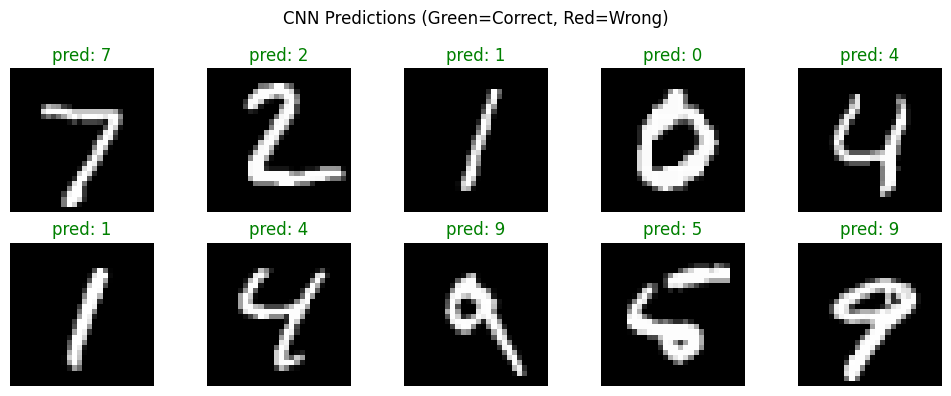

In [22]:
# See Prediction on Real Images

model.eval()
images, labels = next(iter(test_loader))
outputs = model(images)
_, predictions = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
  ax.imshow(images[i].squeeze(), cmap="gray")
  color = "green" if predictions[i] == labels[i] else "red"
  ax.set_title(f"pred: {predictions[i].item()}", color=color)
  ax.axis("off")

plt.suptitle("CNN Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()